# Import

In [ ]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib.pyplot as plt
import os 
import pandas as pd
import numpy as np
from pandas.api.types import CategoricalDtype
from ciim.src.utils.util import retrieve_net
from ciim.src.pathway_analysis.util import get_genesets, pathway_kde_func, get_hallmark, gsea_func, wrapper_gsea
from ciim.src.pathway_analysis.plots import plot_pathway_kde

# - plot
from ciim.src.feature_association.plots import heamap_plot_minor_cell_types

# plt.rcParams["figure.figsize"]=4,4
plt.rcParams["figure.dpi"]=150
# plt.rcParams["savefig.dpi"]=300
plt.rcParams["font.family"] = "Arial"

import warnings
warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import PLOTS_DIR, SAVE_DIR,cell_types, \
     datasets_all, palette_datasets_pretty, palette_datasets, surrogate_names, \
     palette_treatment, colors_blind, palette_trend, palette_trend_2, palette_cell_types, palette_disease_effect

from ciim.src.feature_association.helper import retrieve_sig_net, calculate_tf_activity, retrieve_sig_stats, retrieve_stats_features

from ciim.src.feature_association.plots import plot_net_nx, plot_sig_tfs_stats, plot_analysis_and_centrality, plot_overlap
from ciim.src.utils.util import retrieve_adata, retrieve_net_consensus
from ciim.src.feature_association.helper import wrapper_tf_activity, wrapper_gene_expression, wrapper_association_with_age_condition
from ciim.src.feature_association.disease import plot_healthy_disease_trend
from ciim.src.feature_association.network import select_top_targets
from ciim.src.feature_association.perturbation import run_stats, get_dataset_config

task_grn_inference_dir = '../../task_grn_inference'

ImportError: cannot import name 'run_stats' from 'ciim.src.feature_association.perturbation.config' (/Users/jno24/Documents/projs/ongoing/ciim/src/feature_association/perturbation/config.py)

# Gene expression association

Text(0, 0.5, 'Number of genes')

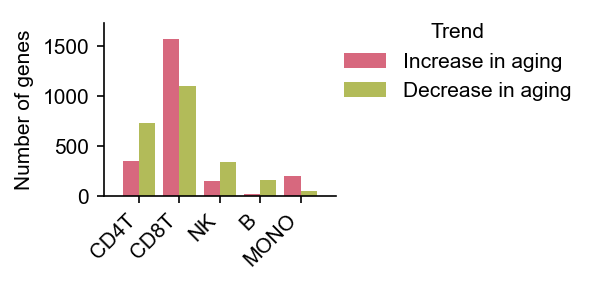

In [ ]:
feature_type = 'gene_expression'
aging_stats_sig = retrieve_sig_stats(type='bulk', race="both", feature_type=feature_type).drop_duplicates(subset=["cell_type", "target"])

stats = aging_stats_sig.copy()
stats['cell_type'] = pd.Categorical(stats['cell_type'], categories=cell_types, ordered=True)
stats.rename(columns={'target':'tf'}, inplace=True)
plot_sig_tfs_stats(stats, figsize=(2, 1.5), palette=palette_trend_2)
plt.ylabel('Number of genes')

# plt.savefig(f'{PLOTS_DIR}//aging_tfs_count.png', bbox_inches='tight', dpi=300, transparent=True)

Available pathways from statistical results: 42
User selected sets: ['Myc Targets V2' 'Myc Targets V1' 'KRAS Signaling Dn'
 'Interferon Gamma Response' 'Oxidative Phosphorylation' 'Adipogenesis'
 'Complement' 'DNA Repair' 'heme Metabolism' 'Allograft Rejection'
 'mTORC1 Signaling' 'Interferon Alpha Response' 'PI3K/AKT/mTOR  Signaling'
 'Reactive Oxygen Species Pathway' 'Mitotic Spindle'
 'Unfolded Protein Response' 'Fatty Acid Metabolism' 'Hypoxia' 'Apoptosis'
 'Protein Secretion' 'UV Response Up' 'Xenobiotic Metabolism' 'Glycolysis'
 'G2-M Checkpoint' 'p53 Pathway' 'Pperoxisome' 'Coagulation' 'E2F Targets'
 'TNF-alpha Signaling via NF-kB' 'Androgen Response' 'Myogenesis'
 'Bile Acid Metabolism' 'Apical Junction' 'Inflammatory Response']
Available pathways: ['Adipogenesis', 'Allograft Rejection', 'Androgen Response', 'Apical Junction', 'Apoptosis', 'Bile Acid Metabolism', 'Cholesterol Homeostasis', 'Coagulation', 'Complement', 'DNA Repair']
After filtering by user selection: 34 pathway

(<Figure size 675x1836 with 1 Axes>, {'CD4T': [], 'CD8T': []})

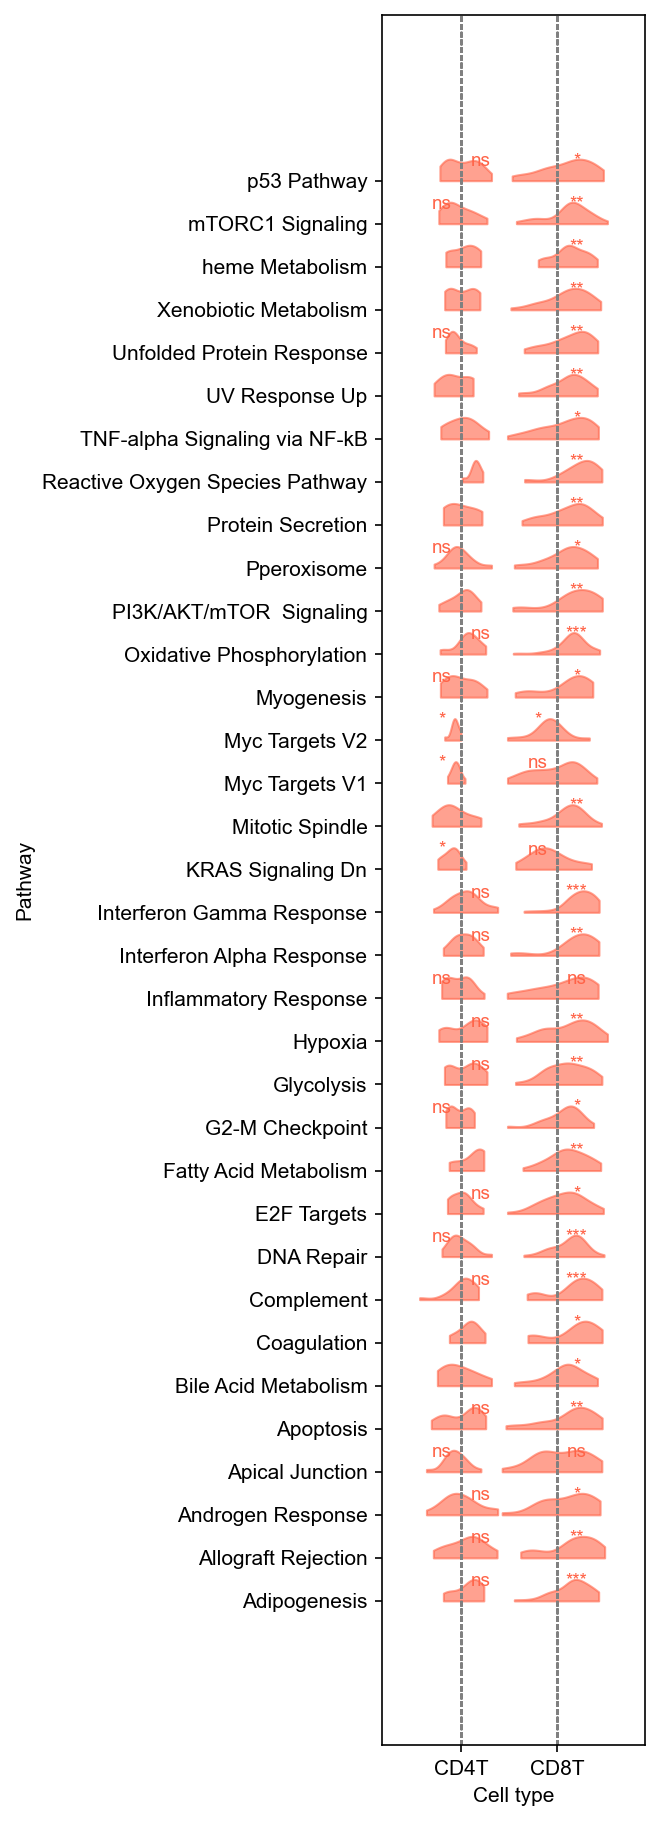

In [ ]:
min_genes=10
results_df = pathway_kde_func(aging_stats_sig, min_genes=min_genes)
sig_rr = results_df[results_df['p_adj'] < 0.05]

sets = sig_rr['gene_set'].unique()
plot_pathway_kde(
    df_aging=aging_stats_sig,
    res_aging=results_df,    
    df_condition=None,
    cell_types=['CD4T', 'CD8T'],
    sets=sets,
    min_genes=10
)

# Pathway analysis

## GSEA

### Aging

In [5]:
for feature_type in ['gene_expression', 'tf_activity']:
    feature_col = 'target' if feature_type=='gene_expression' else 'tf'
    stats_sig_tfs = retrieve_sig_stats(feature_type=feature_type).drop_duplicates(subset=["cell_type", feature_col])
    pathway_scores = gsea_func(stats_sig_tfs, feature_col=feature_col, pvalue_col='meta_p_adj' if feature_type == 'tf_activity' else 'p_value_adj')
    os.makedirs(f'{SAVE_DIR}/pathway_analysis', exist_ok=True)
    pathway_scores.to_csv(f'{SAVE_DIR}/pathway_analysis/gsea_{feature_type}_aging.csv', index=False)

(12, 10)
(3, 10)
(3, 10)
(25, 10)
(25, 10)
(4, 10)
(4, 10)
(6, 10)
(6, 10)
(1, 10)
(1, 10)
(1, 10)
(1, 10)
(7, 10)
(7, 10)
(3, 10)
(3, 10)
(7, 10)
(7, 10)
(6, 10)
(6, 10)
(2, 10)
(2, 10)
(9, 10)
(9, 10)
(4, 10)
(4, 10)


### SLE

In [ ]:
for feature_type in ['tf_activity']: #'gene_expression', 
    dataset = 'SLE_European'
    type = 'bulk'
    test_type = 'unpaired'

    stats = pd.read_csv(f'{SAVE_DIR}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv')

    stats = stats[(~stats['slope_condition'].isna())].copy()

    stats_sig = stats[stats['p_value_adj'] < 0.05].copy()
    stats_sig = stats_sig[stats_sig['age_group']=='Younger than 50']

    stats_sig['trend'] = stats_sig['slope_condition'].apply(lambda x: 'Increase in disease' if x > 0 else 'Decrease in disease')

    pathway_scores = gsea_func(stats_sig, feature_col='tf' if feature_type == 'tf_activity' else 'target', pvalue_col='p_value_adj')
    pathway_scores.to_csv(f'{SAVE_DIR}/pathway_analysis/gsea_{feature_type}_sle.csv', index=False)
    print(pathway_scores.head())

(1, 10)
(12, 10)
(12, 10)
(3, 10)
(3, 10)
(11, 10)
(11, 10)
(1, 10)
(1, 10)
(11, 10)
(11, 10)
(6, 10)
(6, 10)
(1, 10)
(1, 10)
(7, 10)
               Gene_set                           Term Overlap       P-value  \
0  MSigDB_Hallmark_2020     Wnt-beta Catenin Signaling    3/42  1.115464e-05   
0  MSigDB_Hallmark_2020  TNF-alpha Signaling via NF-kB  24/200  7.297062e-24   
1  MSigDB_Hallmark_2020      Interferon Gamma Response  11/200  7.225380e-08   
2  MSigDB_Hallmark_2020                        Hypoxia  10/200  6.994071e-07   
3  MSigDB_Hallmark_2020      Interferon Alpha Response    7/97  3.128593e-06   

            FDR  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  1.673196e-04            0                     0   85.213675   
0  2.481001e-22            0                     0   25.577922   
1  1.228315e-06            0                     0    9.707739   
2  7.926613e-06            0                     0    8.704556   
3  2.659304e-05            0                     0   12

### Drugs

In [ ]:
for feature_type in ['tf_activity']: #'gene_expression'
    # dataset = 'CXCL9'
    for dataset in ['CXCL9', 'op']:
        stats = pd.read_csv(f"{SAVE_DIR}/stats/stats_{dataset}_{feature_type}.csv")
        stats_sig = stats[stats["p_value_adj"] < 0.05].copy()
        stats_sig['trend'] = stats_sig['slope_condition'].apply(lambda x: 'Increase after treatment' if x > 0 else 'Decrease after treatment')
        pathway_scores = gsea_func(stats_sig, feature_col='tf' if feature_type == 'tf_activity' else 'target', pvalue_col='p_value_adj')
        pathway_scores.to_csv(f'{SAVE_DIR}/pathway_analysis/gsea_{feature_type}_drugs_{dataset}.csv', index=False)
        print(pathway_scores.head())

(10, 10)
(9, 10)
(9, 10)
(8, 10)
(8, 10)
(3, 10)
(3, 10)
(5, 10)
(5, 10)
(15, 10)
(15, 10)
(7, 10)
(7, 10)
(6, 10)
(6, 10)
(4, 10)
(4, 10)
(12, 10)
               Gene_set                           Term Overlap       P-value  \
0  MSigDB_Hallmark_2020  TNF-alpha Signaling via NF-kB  22/200  1.771545e-21   
1  MSigDB_Hallmark_2020      Interferon Gamma Response  10/200  4.846034e-07   
2  MSigDB_Hallmark_2020           IL-2/STAT5 Signaling   9/199  4.221918e-06   
3  MSigDB_Hallmark_2020                        Hypoxia   9/200  4.398023e-06   
4  MSigDB_Hallmark_2020       IL-6/JAK/STAT3 Signaling    6/87  1.685228e-05   

            FDR  Old P-value  Old Adjusted P-value  Odds Ratio  \
0  6.377561e-20            0                     0   23.868473   
1  8.722862e-06            0                     0    9.088643   
2  3.958221e-05            0                     0    8.108650   
3  3.958221e-05            0                     0    8.065786   
4  1.213364e-04            0             

(10, 10)
(4, 10)
(4, 10)
(4, 10)
(4, 10)
(13, 10)
(13, 10)
(7, 10)
(7, 10)
(8, 10)
(8, 10)
(4, 10)
(4, 10)
(6, 10)
(6, 10)
Available pathways from statistical results: 5
User selected sets: ['Interferon Gamma Response' 'TNF-alpha Signaling via NF-kB' 'Hypoxia'
 'IL-2/STAT5 Signaling' 'TNF-alpha Signaling via NF-kB']
Available pathways: ['Hypoxia', 'IL-2/STAT5 Signaling', 'Interferon Gamma Response', 'TNF-alpha Signaling via NF-kB', 'p53 Pathway']
After filtering by user selection: 4 pathways
  ✓ Added Hypoxia to valid sets
  ✓ Added IL-2/STAT5 Signaling to valid sets
  ✓ Added Interferon Gamma Response to valid sets
Valid pathways after filtering: 4 out of 6
Valid pathways: ['Hypoxia', 'IL-2/STAT5 Signaling', 'Interferon Gamma Response', 'TNF-alpha Signaling via NF-kB']...
Available pathways from statistical results: 5
User selected sets: ['Interferon Gamma Response' 'TNF-alpha Signaling via NF-kB' 'Hypoxia'
 'IL-2/STAT5 Signaling' 'TNF-alpha Signaling via NF-kB']
Available pathways: [

(<Figure size 525x300 with 1 Axes>, {'CD4T': []})

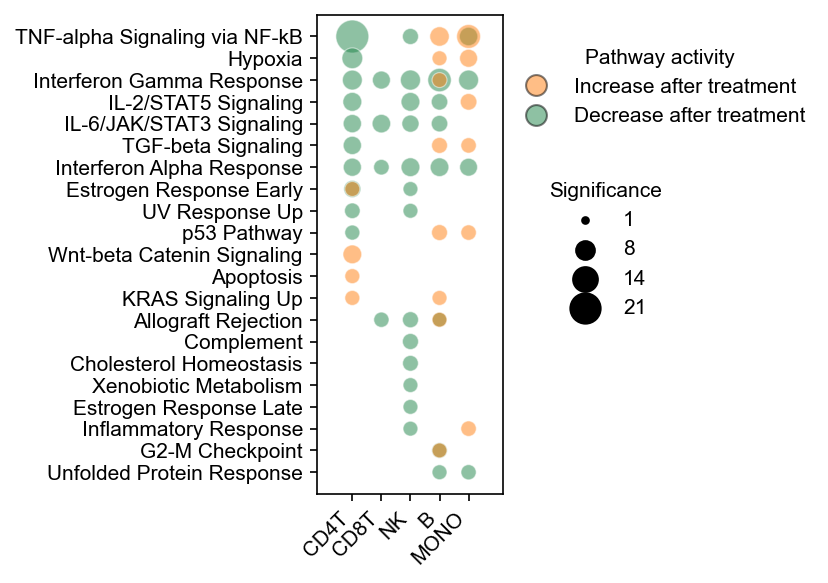

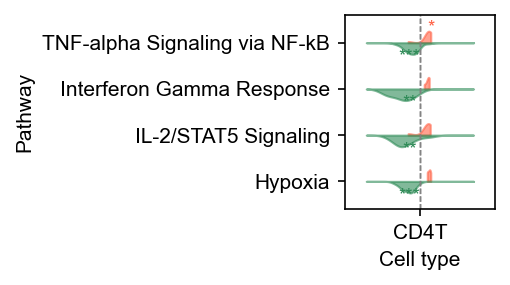

In [ ]:
stats_sig['trend'] = ['Increase after treatment' if x > 0 else 'Decrease after treatment' for x in stats_sig['slope_condition']]
wrapper_gsea(stats_sig, palette=palette_treatment, pvalue_col='p_value_adj', feature_col='tf')

aging_stats_sig = retrieve_sig_stats(type='bulk', race="both", feature_type='tf_activity').drop_duplicates(subset=["cell_type", "tf"])

aging_stats_sig = aging_stats_sig[aging_stats_sig['cell_type']=='CD4T']
res_aging = pathway_kde_func(aging_stats_sig, min_genes=10, feature_col='tf')
res_aging_sig = res_aging[res_aging['p_adj'] < 0.05]

stats_sig['slope'] = stats_sig['slope_condition']
res_condition = pathway_kde_func(stats_sig, min_genes=10, feature_col='tf')
res_condition_sig = res_condition[res_condition['p_adj'] < 0.05]

sets = np.concatenate([res_condition_sig['gene_set'].unique(), res_aging_sig['gene_set'].unique()])

plot_pathway_kde(
    df_aging=aging_stats_sig,
    res_aging=res_aging,
    df_condition=stats_sig,
    res_cond=res_condition,
    cell_types=['CD4T'],
    sets=sets,
    min_genes=2,
    max_height=0.1,
    row_spacing=0.4,
    cell_spacing=1.5,
    feature_col='tf',
)
# plt.savefig(f"{PLOTS_DIR}/{dataset}_aging_pathway.png", bbox_inches="tight", dpi=300, transparent=True)

## Pathway gene score

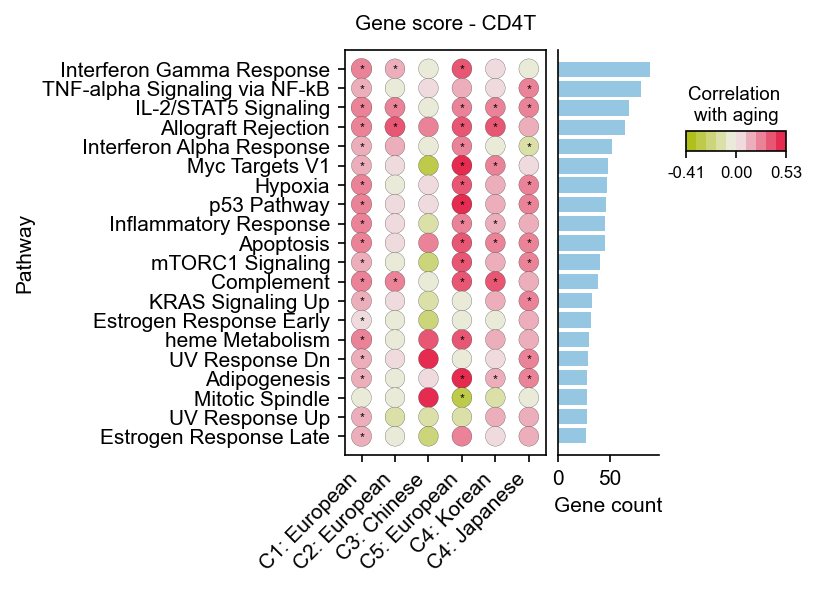

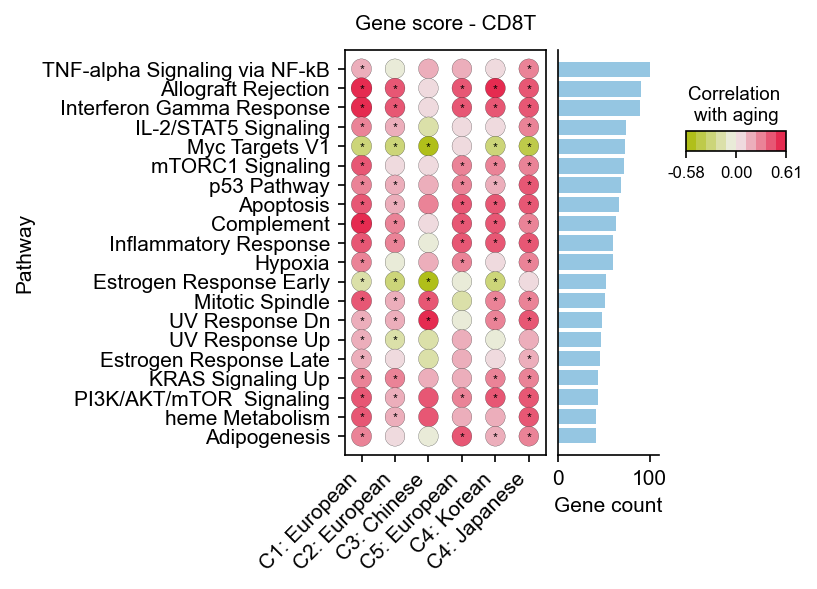

In [20]:
from ciim.src.feature_association.plots import plot_gene_score_association_with_age, plot_features_vs_datasets, plot_feature_values_per_datasets
feature_type='gene_score'
ttypes = ['CD4T', 'CD8T']
type = 'bulk'
filter_meta_significant=False
features = ['Interferon Gamma Response', 'TNF-alpha Signaling via NF-kB',
       'Interferon Alpha Response', 'IL-2/STAT5 Signaling',
       'Allograft Rejection', 'Apoptosis', 'Myc Targets V1', 'Hypoxia',
       'p53 Pathway', 'Inflammatory Response', 'mTORC1 Signaling',
       'IL-6/JAK/STAT3 Signaling', 'Complement', 'Androgen Response',
       'UV Response Dn', 'PI3K/AKT/mTOR  Signaling', 'KRAS Signaling Up',
       'UV Response Up', 'Estrogen Response Early',
       'Unfolded Protein Response', 'TGF-beta Signaling',
       'heme Metabolism', 'Mitotic Spindle', 'Adipogenesis',
       'Reactive Oxygen Species Pathway', 'Estrogen Response Late',
       'Apical Junction', 'Cholesterol Homeostasis', 'Protein Secretion',
       'G2-M Checkpoint']
# features = None
# filter_meta_significant=True
for cell_type in ttypes:
    plot_gene_score_association_with_age(cell_type=cell_type, type=type, datasets=datasets_all, features=features, width=3.5,
                                feature_type=feature_type, sizes=(90, 100), min_degree=1, race='both', 
                                filter_meta_significant=filter_meta_significant,
                                margins_ax1={'x': 0.1, 'y': 0.05}, margins_ax2={'x': 0.1, 'y': 0.03}, figsize=[3.5, 3.5],
                                n_top_terms=20)
    plt.savefig(os.path.join(PLOTS_DIR, f'{cell_type}_gene_score_association_with_age.png'), bbox_inches='tight', dpi=300, transparent=True)
    # plot_feature_values_per_datasets(cell_type, features, type, datasets_all, feature_type=feature_type, age_limit=[20, 75], cluster=False, figsize=[10, 2])

# Aging TFs

## Run feature calculation and association

In [ ]:
# !cd ../ && bash scripts/run_association_analysis.sh

## Heatmap of sig TFs across cell types and cohorts

In [22]:
type = 'bulk'
stats_all = retrieve_stats_features(type, feature_type='tf_activity', condition='healthy')
# print(stats_all)

In [23]:
# - add sig signs
stats_sig = retrieve_sig_stats(type)

tuple_index = stats_sig.set_index(['cell_type', 'tf', 'dataset']).index

stats_all = stats_all.set_index(['cell_type', 'tf', 'dataset'])
stats_all['is_significant'] = False
stats_all.loc[tuple_index, 'is_significant'] = True

stats_all = stats_all.reset_index()[['tf', 'cell_type', 'dataset', 'slope', 'is_significant']].drop_duplicates()

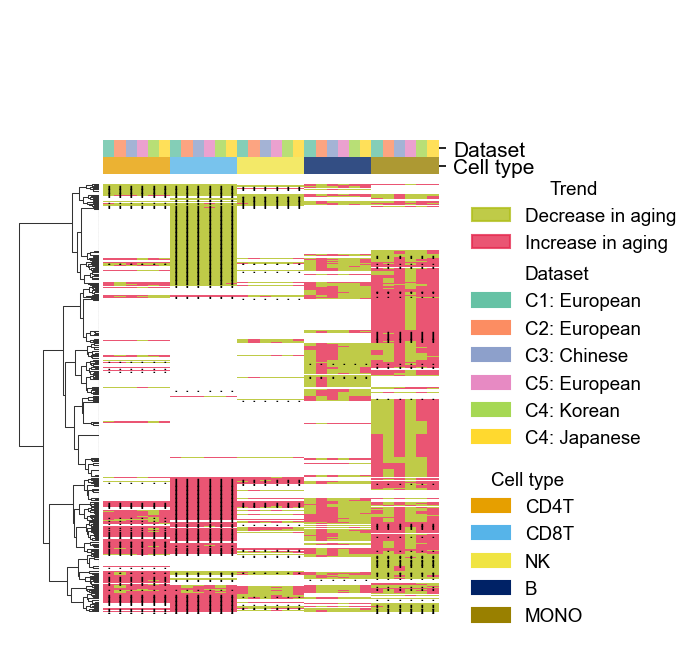

In [24]:
from ciim.src.feature_association.plots import plot_overall_heatmap

stats_all['cell_type'] = pd.Categorical(stats_all['cell_type'], categories=cell_types, ordered=True)
stats_all['dataset'] = pd.Categorical(stats_all['dataset'], categories=datasets_all, ordered=True)

plot_overall_heatmap(stats_all, 
                    sig_dots_y_offset=3, 
                    first_col='cell_type',  first_col_palette=palette_cell_types,
                    second_col='dataset', second_col_palette=palette_datasets,
                    bbox_to_anchor=(1.05, 1.05),
                    bbox_to_anchor_col2=(1.05, .85),
                    bbox_to_anchor_col1=(1.05, 0.37),
                    figsize=(4, 6),
                    map_names={**{'cell_type':'Cell type', 'dataset': 'Dataset'}, **surrogate_names})
plt.savefig(f'{PLOTS_DIR}//overall_heatmap.png', bbox_inches='tight', dpi=300)

## Sig TFs counts

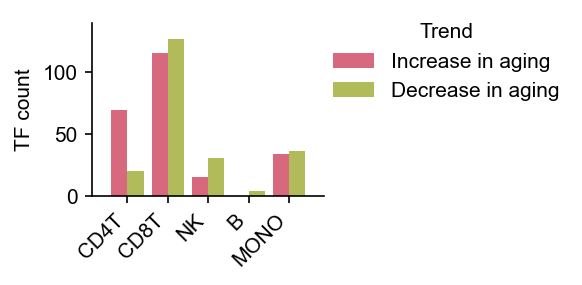

In [25]:
aging_stats_sig = retrieve_sig_stats(type='bulk', filter_inconsistent=True).drop_duplicates(subset=['cell_type', 'tf'])
# plt.savefig(f'../output/tf_activity/trends.png', dpi=300)
aging_stats_sig['cell_type'] = pd.Categorical(aging_stats_sig['cell_type'], categories=cell_types, ordered=True)
plot_sig_tfs_stats(aging_stats_sig, figsize=(2, 1.5), palette=palette_trend_2)
# plt.title(f'Number of aging TFs', pad=15, fontsize=10, weight='bold')
plt.savefig(f'{PLOTS_DIR}//aging_tfs_count.png', bbox_inches='tight', dpi=300, transparent=True)

## Identify sig networks

In [26]:
from ciim.src.feature_association.helper import determine_sig_network

type = 'bulk'

if True:
    determine_sig_network(type, min_degree=3)

In [27]:
sig_net = retrieve_sig_net()
sig_net_size = sig_net.groupby('cell_type').size()
sig_net_size = sig_net_size.reindex(cell_types, fill_value=0).reset_index()

sig_net_size

,cell_type,0
0,CD4T,2927
1,CD8T,30207
2,NK,629
3,B,13
4,MONO,3495


Text(0.5, 1.0, 'Aging GRNs size')

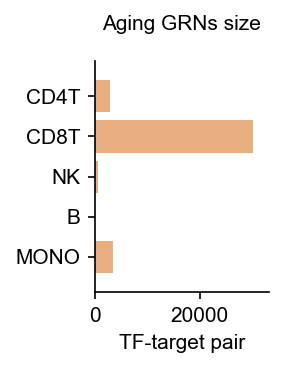

In [28]:
# Reindex to desired order and reset index

sig_net_size.columns = ['cell_type', 'edge_count']

# Ensure categorical order for plotting
sig_net_size['cell_type'] = pd.Categorical(sig_net_size['cell_type'], categories=cell_types, ordered=True)
sig_net_size = sig_net_size.sort_values('cell_type')

# Plot
fig, ax = plt.subplots(figsize=(1.5, 2))
ax.barh(sig_net_size['cell_type'], sig_net_size['edge_count'], color=colors_blind[5], alpha=.5)

# Aesthetics
ax.invert_yaxis()
ax.set_xlabel('TF-target pair')
ax.set_ylabel('')
ax.spines[['top', 'right']].set_visible(False)
ax.margins(y=0.1, x=0.1)
# ax.set_xscale('log')
ax.set_title('Aging GRNs size', weight='bold', fontsize=10, pad=15)

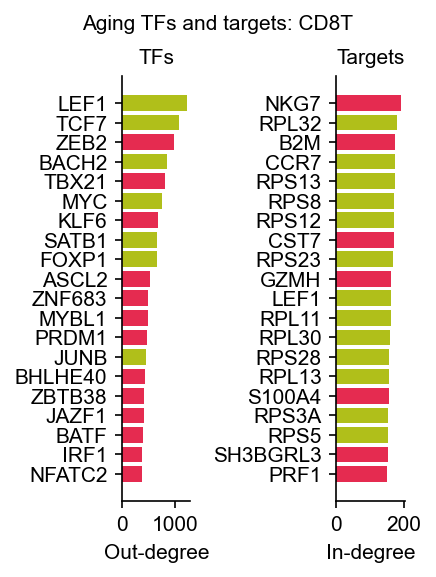

In [29]:
import matplotlib.pyplot as plt

n_top = 20
cell_type = 'CD8T'
df = sig_net[sig_net['cell_type'] == cell_type]

# Compute top source and target degrees
source_counts = df['source'].value_counts().head(n_top).reset_index()
source_counts.columns = ['source', 'degree']
source_info = df[['source', 'trend_source']].drop_duplicates(subset='source')
source_df = source_counts.merge(source_info, on='source', how='left')

target_counts = df['target'].value_counts().head(n_top).reset_index()
target_counts.columns = ['target', 'degree']
target_info = df[['target', 'trend_target']].drop_duplicates(subset='target')
target_df = target_counts.merge(target_info, on='target', how='left')

# Setup plot
fig, axes = plt.subplots(1, 2, figsize=(3, 4), sharey=False)

# Plot sources
source_colors = source_df['trend_source'].map(palette_trend).values
target_colors = target_df['trend_target'].map(palette_trend).values[::-1]
axes[0].barh(source_df['source'], source_df['degree'], color=source_colors)
axes[0].set_title('TFs', fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Out-degree')
axes[0].spines[['top', 'right']].set_visible(False)

# Plot targets
axes[1].barh(target_df['target'][::-1], target_df['degree'][::-1], color=target_colors)
axes[1].set_title('Targets', fontsize=10)
axes[1].set_xlabel('In-degree')
axes[1].spines[['top', 'right']].set_visible(False)

# Title and layout
fig.suptitle(f'Aging TFs and targets: {cell_type}', fontsize=10, weight='bold', y=.95)
from matplotlib.patches import Patch

legend_elements = [Patch(facecolor=color, label=label) for label, color in palette_trend_2.items()]
# fig.legend(handles=legend_elements, bbox_to_anchor=(1.5, .8), fontsize=10, frameon=False, title='Trend', title_fontsize=10)
fig.tight_layout()

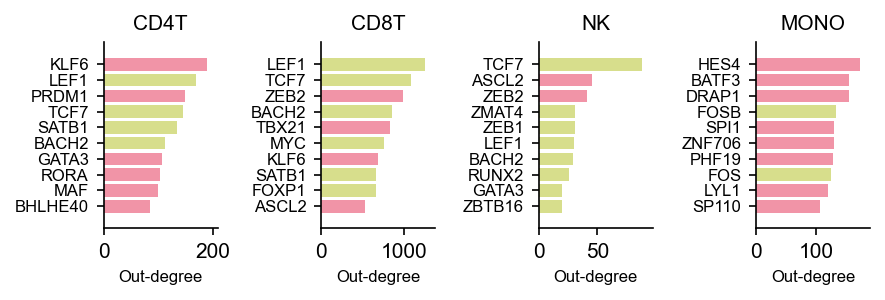

In [30]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Parameters
n_top = 10
cell_types_selected = ['CD4T', 'CD8T', 'NK', 'MONO']
focus = 'source'  # can be 'source' or 'target'
trend_col = 'trend_source' if focus == 'source' else 'trend_target'
palette = palette_trend_2  # assume this dict is defined

# Collect top TFs across cell types
rows = []
for ct in cell_types_selected:
    df_ct = sig_net[sig_net['cell_type'] == ct]
    counts = df_ct[focus].value_counts().head(n_top).reset_index()
    counts.columns = [focus, 'degree']
    trends = df_ct[[focus, trend_col]].drop_duplicates(subset=focus)
    merged = counts.merge(trends, on=focus, how='left')
    merged['cell_type'] = ct
    rows.append(merged)

plot_df = pd.concat(rows, ignore_index=True)

# Sort TFs within each cell type
plot_df[focus] = plot_df[focus].astype(str)
plot_df = plot_df.sort_values(by=['cell_type', 'degree'], ascending=[True, False])

# Setup plot
n_cols = len(cell_types_selected)
fig, axes = plt.subplots(1, n_cols, figsize=(1.5*n_cols, 2.1 ), sharex=False)

if n_cols == 1:
    axes = [axes]

for ax, ct in zip(axes, cell_types_selected):
    df_ct = plot_df[plot_df['cell_type'] == ct]
    colors = df_ct[trend_col].map(palette)
    ax.barh(df_ct[focus], df_ct['degree'], color=colors, alpha=0.5)
    ax.set_title(f'{ct}', fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Out-degree' if focus == 'source' else 'In-degree', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
    ax.margins(x=0.1, y=0.1)
    ax.spines[['top', 'right']].set_visible(False)
# Title and legend
# fig.suptitle(f'Central aging {"TFs" if focus == "source" else "targets"}', fontsize=12, weight='bold', y=0.96)
legend_elements = [Patch(facecolor=color, label=label) for label, color in palette.items()]
# fig.legend(handles=legend_elements, bbox_to_anchor=(1.01, 0.8), loc='upper left', title='Trend', title_fontsize=10, frameon=False)
fig.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, f'central_aging_{focus}.png'), bbox_inches='tight', dpi=300, transparent=True)


## Interaction of aging TFs between cell types

### T cells

In [33]:
from grn_benchmark.src.exp_analysis.helper import plot_interactions, create_interaction_df

type = 'bulk'
stats_sig = retrieve_sig_stats(type=type).drop_duplicates(subset=['cell_type', 'tf'])
df_dict = stats_sig.groupby(['cell_type'])['tf'].apply(list).to_dict()
interaction_main_df = create_interaction_df(df_dict)

['CD8T', 'CD4T', 'MONO', 'NK', 'B']


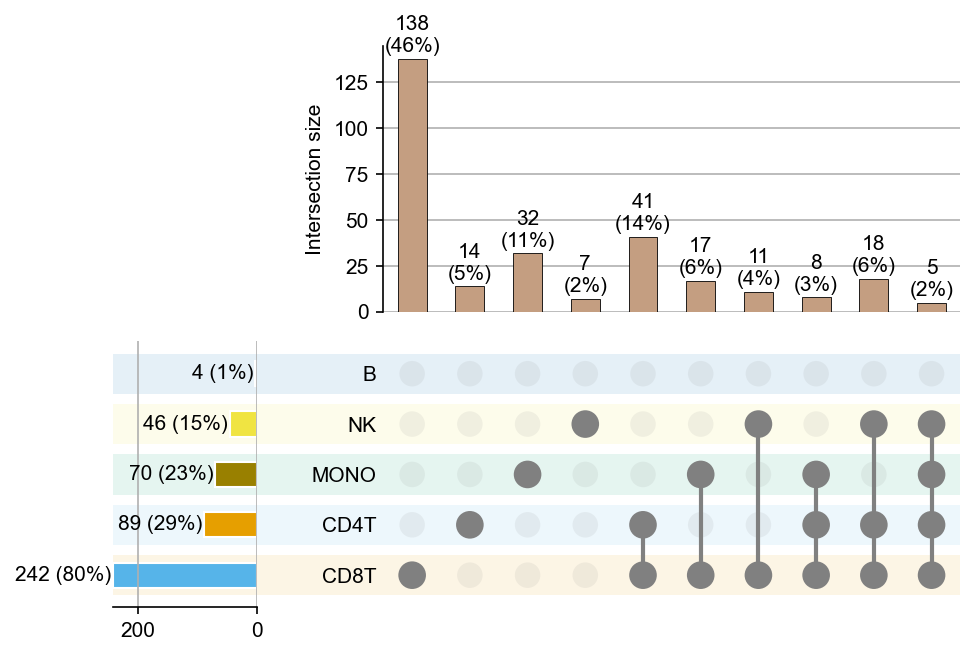

In [34]:
aa = plot_interactions(interaction_main_df, min_subset_size=5, min_degree=1, color_map=palette_cell_types)
plt.savefig(f'{PLOTS_DIR}/interactions.png', dpi=300, transparent=True, bbox_inches='tight')
# plt.title(surrogate_names[race], pad=40, fontsize=10, fontweight='bold')

In [35]:
# interaction_main_df.loc['TBX21']

In [36]:
ttypes = ['CD8T', 'CD4T', 'NK']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index.unique()
print(len(features))

23


23


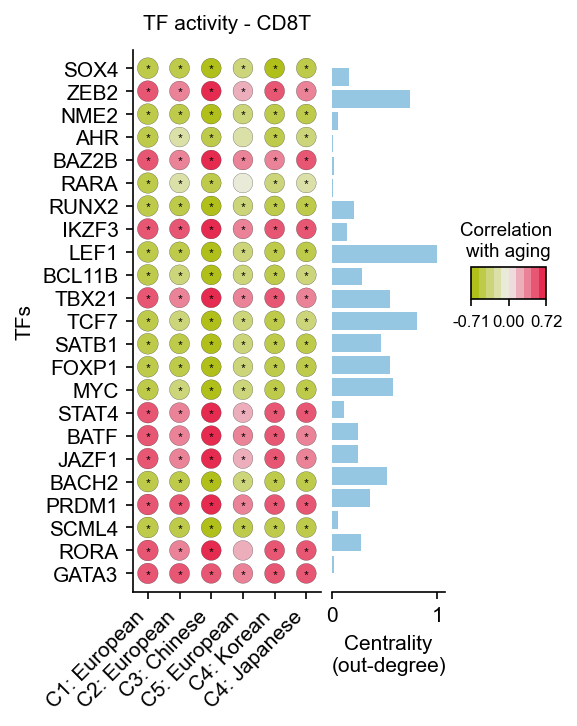

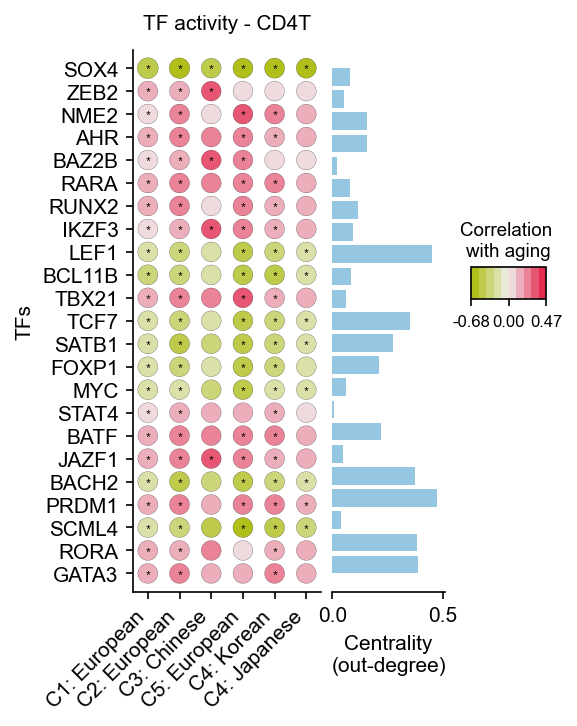

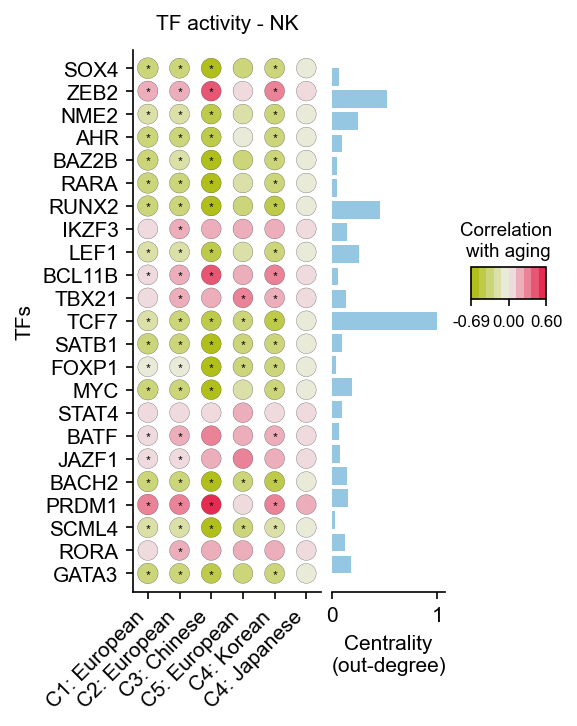

In [40]:
from ciim.src.feature_association.plots import plot_features_vs_datasets

ttypes = ['CD8T', 'CD4T', 'NK']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index.unique()
print(len(features))
for cell_type in ttypes:
    plot_features_vs_datasets(cell_type=cell_type, type=type, datasets=datasets_all, features=features, 
                                feature_type='tf_activity', sizes=(90, 100), min_degree=1, race='both', 
                                filter_meta_significant=True,
                                )
    plt.savefig(f'{PLOTS_DIR}//shared_aging_tfs_{cell_type}', bbox_inches='tight', dpi=300, transparent=True)

### Shared sig TFs between CD8T and CD4T

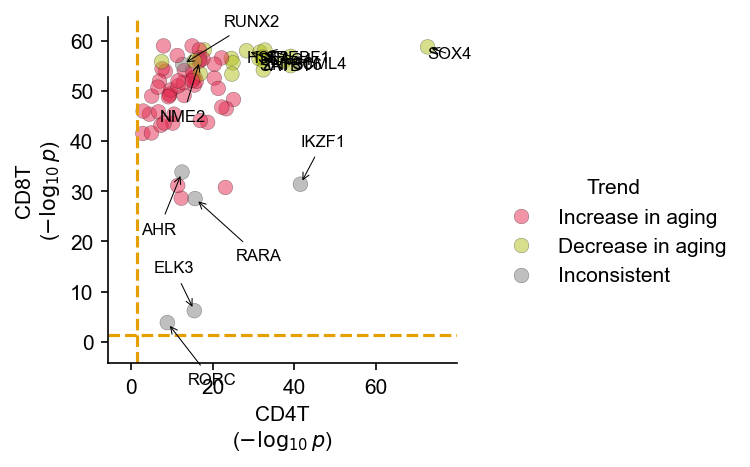

In [41]:
from ciim.src.feature_association.plots import plot_joint_scatter

ttypes = ['CD8T', 'CD4T']
mask = interaction_main_df[ttypes].sum(axis=1)==len(ttypes)
features = mask[mask].index
# Get significant TFs for CD4T and CD8T cells
df = stats_sig[stats_sig['tf'].isin(features)].drop_duplicates(subset=['cell_type', 'tf'])
df['neg_log10_adj_pval'] = -np.log10(df['meta_p_adj'])

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
plot_joint_scatter(df, vars=['CD4T', 'CD8T'], annotate=True, ax=ax)
ax.margins(x=0.1, y=0.1)

## GSEA

(1, 10)
(7, 10)
(7, 10)
(3, 10)
(3, 10)
(7, 10)
(7, 10)
(6, 10)
(6, 10)
(2, 10)
(2, 10)
(9, 10)
(9, 10)
(4, 10)
(4, 10)


(<Figure size 240x532.5 with 1 Axes>, <Axes: >)

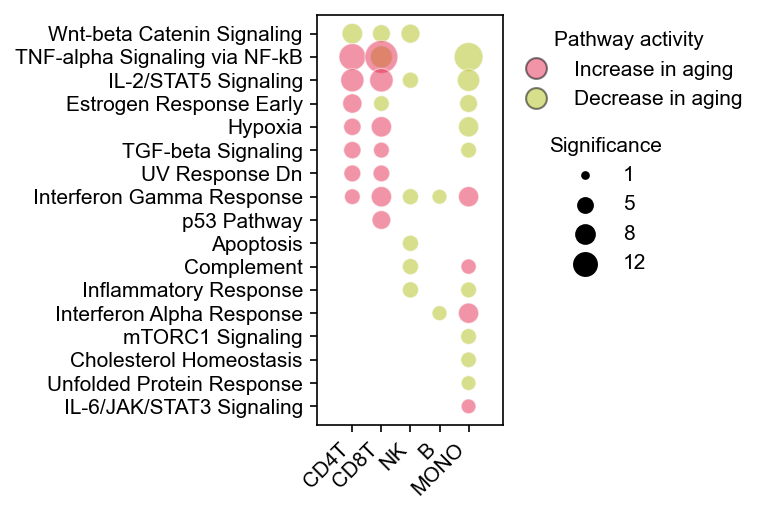

In [43]:
wrapper_gsea(stats_sig, feature_type='tf_activity')
# ax.set_title(surrogate_names[race], fontsize=10, fontweight='bold')

In [ ]:
pathway_scores['Term'].unique()

array(['Myc Targets V2', 'Wnt-beta Catenin Signaling',
       'IL-2/STAT5 Signaling', 'TNF-alpha Signaling via NF-kB',
       'Interferon Gamma Response', 'p53 Pathway',
       'Oxidative Phosphorylation', 'Allograft Rejection', 'Apoptosis',
       'PI3K/AKT/mTOR  Signaling', 'Reactive Oxygen Species Pathway',
       'heme Metabolism', 'Hypoxia', 'mTORC1 Signaling', 'Complement',
       'Inflammatory Response', 'Glycolysis', 'Protein Secretion',
       'Cholesterol Homeostasis', 'DNA Repair',
       'Interferon Alpha Response', 'UV Response Dn', 'Androgen Response',
       'Adipogenesis', 'Epithelial Mesenchymal Transition',
       'IL-6/JAK/STAT3 Signaling', 'Myc Targets V1', 'Mitotic Spindle',
       'G2-M Checkpoint', 'Unfolded Protein Response', 'Pperoxisome',
       'Fatty Acid Metabolism', 'E2F Targets', 'Bile Acid Metabolism',
       'UV Response Up', 'TGF-beta Signaling', 'Estrogen Response Early',
       'Notch Signaling', 'Angiogenesis', 'Estrogen Response Late'],
      dtype

## Case TF

In [45]:
case_tf = 'SATB1'  # 'TCF7' 'SATB1' 
type = 'bulk'
race = 'both'
n_top_targets = 10
selected_cell_types = ['CD8T', 'CD4T', 'NK'] # ['CD8T', 'CD4T', 'NK'] #Tcm_Naive_CD8
n_panels = len(selected_cell_types)

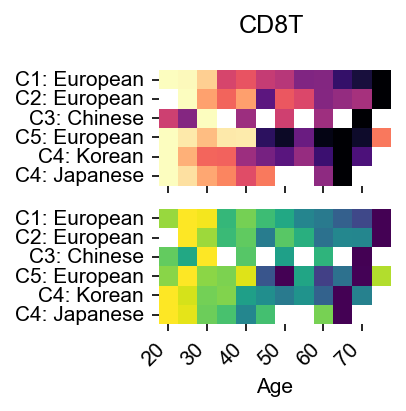

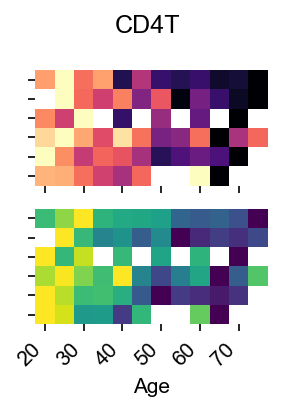

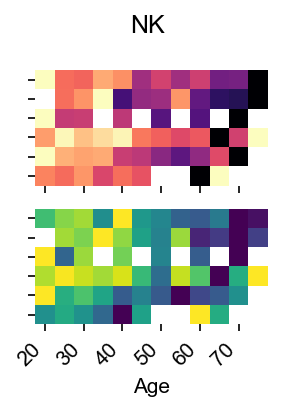

In [46]:
from ciim.src.feature_association.plots import plot_feature_values_all_datasets, plot_feature_values_per_datasets
type = 'bulk'

if '_M' in type:
    datasets = ['data1', 'data7_allTPs_jalil', 'data13_Korean']
elif '_F' in type:
    datasets = ['data1', 'SLE_European', 'data13_Korean']
else:
    # datasets = ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Korean']
    datasets = datasets_all

plot_both = True
show_cbar=False


for i, cell_type in enumerate(selected_cell_types):
    if i == 0:
        show_ylabels=True
    else:
        show_ylabels=False
    
    if plot_both:
        fig, axes = plt.subplots(2, 1, figsize=(2, 2.2), sharex=True)
    else:
        fig, ax = plt.subplots(1, 1, figsize=(2, .7))

    ax = axes[0] if plot_both else ax
    plot_feature_values_all_datasets(cell_type, feature=case_tf, feature_type='tf_activity', type=type, datasets=datasets, show_cbar=show_cbar, ax=ax,
                                     show_ylabels=show_ylabels)
    if plot_both:
        ax.set_xlabel('')
        ax = axes[1]
        plot_feature_values_all_datasets(cell_type, feature=case_tf, feature_type='gene_expression', 
                                        type=type, datasets=datasets, show_cbar=show_cbar, ax=ax, show_ylabels=show_ylabels)
    
    plt.suptitle(f'{cell_type}', y=1.05)
    plt.savefig(f'{PLOTS_DIR}/{case_tf}_{cell_type}.png', bbox_inches='tight', dpi=300)

In [47]:
nets_sig = pd.read_csv(f'{SAVE_DIR}/sig_nets/sig_nets_{type}_{race}.csv')
nets_sig = nets_sig[(nets_sig['source']==case_tf) & (nets_sig['cell_type'].isin(selected_cell_types))].copy()
n_targets = 10

In [48]:
stats_targets = retrieve_sig_stats(type, feature_type='gene_expression', race=race)

targets_store = []
for cell_type in selected_cell_types:
    net = nets_sig[nets_sig['cell_type']==cell_type]
    targets = net.sort_values('weight', ascending=False, key=abs).head(n_targets)['target'].unique()
    targets_store.append(targets)
all_targets = np.concatenate(targets_store)

net_store = []
for cell_type in selected_cell_types:
    net = select_top_targets(cell_type, case_tf, datasets, all_targets, n_top=n_top_targets)
    net['cell_type'] = cell_type
    net_store.append(net)
net_tf = pd.concat(net_store)

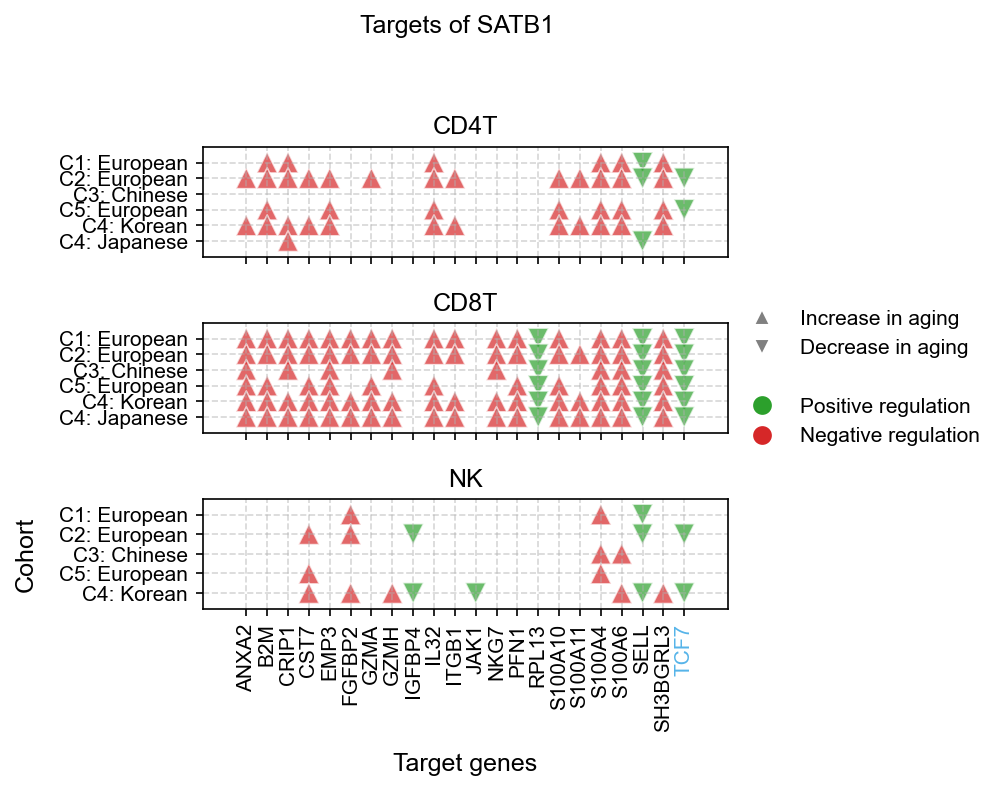

In [49]:
from ciim.src.feature_association.plots import wrapper_flesh_out_tf_interactions, plot_tf_interactions_plus_target_stats_binary

n_top_genes_per_dataset=10
# - select 
shared_state = net_tf.groupby(['cell_type','target'])['dataset'].nunique()
selected_tuple = shared_state[shared_state>=3].index
net_tf = net_tf.set_index(['cell_type', 'target']).loc[selected_tuple].reset_index()

n_targets = net_tf['target'].nunique()
net_tf['target'] = net_tf['target'].astype('category')
net_tf['dataset'] = pd.Categorical(net_tf['dataset'], categories=datasets_all, ordered=True)
fig, axes = plt.subplots(n_panels, 1, figsize=(n_targets*.16 +1, len(datasets_all)*.5 + 1), sharex=True)

for i, (cell_type) in enumerate(net_tf['cell_type'].unique()):
    ax = axes[i] if n_panels > 1 else axes
    if i == 1:
        show_legend = True
    else:
        show_legend = False
    net = net_tf[net_tf['cell_type'] == cell_type]   
    net = net[net['neg_log10_adj_pval'] > 1.4]
    
    plot_tf_interactions_plus_target_stats_binary(net.copy(), ax=ax, show_legend=show_legend, sizes=(50, 200), annotate_sig=False, annotate_targets=True)

    ax.margins(y=0.2, x=0.1)
    ax.set_title(cell_type)
    ax.set_xlabel('Target genes')
    ax.grid(True, linestyle='--', alpha=0.5)
    if i != n_panels - 1:
        ax.set_ylabel('')
plt.suptitle(f'Targets of {case_tf}', y=1.1, weight='bold', fontsize=12)
plt.subplots_adjust(hspace=0.6)

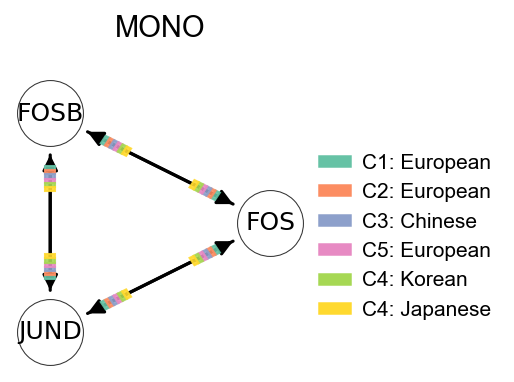

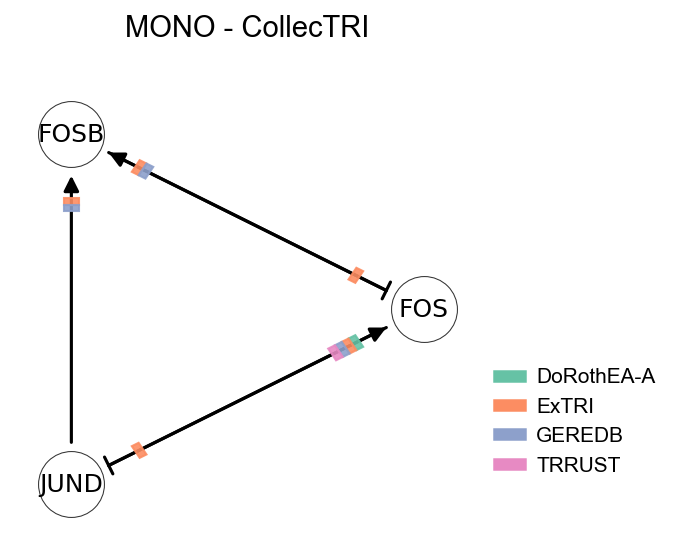

In [50]:
type = 'bulk'
cell_type = 'CD4T' #'Tcm_Naive_CD8'
n_top=10
# features = ['FOXO1', 'FOXO3', 'NFE2L2', 'TP53', 'SIRT1', 'HIF1A']
# features = ['GATA3', 'S100A4', 'GZMK', 'KLF6', 'COTL1', 'TCF7', 'ANXA1']
# features = ['GATA3', 'S100A4', 'GZMK', 'COTL1']
features = ['FOS', 'FOSB', 'JUND']
from ciim.src.feature_association.plots import wrapper_draw_net
for cell_type in ['MONO']:
    wrapper_draw_net(cell_type, datasets_all, features, min_degree=3, indivitual_net=False, draw_evidence=True, draw_collectri=True, figsize=(2.5, 2.5), figsize_collectri=(4, 4), 
                    offset_evidence=.13, arc_offset=.05, only_promotor_based=False)

# Disease

In [51]:
feature_type = 'tf_activity'
data_type = 'bulk'
dataset = 'SLE_European'
# !cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset {dataset} --cell-types "CD4T CD8T" --data-type {data_type} --feature-type {feature_type} --skip-features

In [56]:
# !cd ../ && python src/experiments/disease_sle.py --dataset {dataset} --data-type {data_type} --feature-type {feature_type} --cell-types CD8T CD4T

# Perturbations

In [95]:
feature_type = 'tf_activity'
# !cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset op --cell-types "CD4T CD8T" --data-type sc --feature-type {feature_type}
# !cd ../ && python src/experiments/perturbation_all.py --dataset op --data-type sc --feature-type {feature_type} --cell-types CD4T CD8T

# !cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset CXCL9 --cell-types "CD4T CD8T" --data-type sc --feature-type {feature_type}
# !cd ../ && python src/experiments/perturbation_all.py --dataset CXCL9 --data-type sc --feature-type {feature_type} --cell-types CD4T CD8T

# !cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset parsebioscience --cell-types "CD4T CD8T" --data-type bulk --feature-type {feature_type}
# !cd ../ && python src/experiments/perturbation_all.py --dataset parsebioscience --data-type bulk --feature-type {feature_type} --cell-types CD4T CD8T

In [100]:
# !cd ../ && bash scripts/experiment/run_condition_analysis.sh --dataset soundlife --cell-types "CD4T CD8T" --data-type bulk --feature-type {feature_type}
!cd ../ && python src/experiments/perturbation_all.py --dataset soundlife --data-type bulk --feature-type {feature_type} --cell-types CD4T CD8T

Perturbation Analysis - Post-run Visualization
Dataset: soundlife
Data type: bulk
Feature type: tf_activity
Output directory: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/
Cell types: CD4T, CD8T
Significance threshold: 0.05

Loading statistics...
Total significant TFs per cell type:
cell_type
CD4T     33
CD8T    184
Name: tf, dtype: int64

Generating coverage/overlap plots...
  Processing cell type: CD4T
    Overlap with aging TFs: 31
      Same direction: 31 (100.0%)
      Opposite direction: 0 (0.0%)
  Saved: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/drug_aging_overlap_soundlife_Older__55-65y__CD4T.png
  Processing cell type: CD8T
    Overlap with aging TFs: 176
      Same direction: 126 (71.6%)
      Opposite direction: 50 (28.4%)
  Saved: /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//plots/drug_aging_overlap_soundlife_Older__55-65y__CD8T.png
  Processing cell type: CD4T
    Saved: /Users/jno24/Documents/projs/ongoing/

# Trajectory plot: TF acitvity with age


(981, 119)
(313, 279)
(61, 267)
(150, 113)
(981,) (981,) (981,)
(313,) (313,) (313,)
(61,) (61,) (61,)
(150,) (150,) (150,)


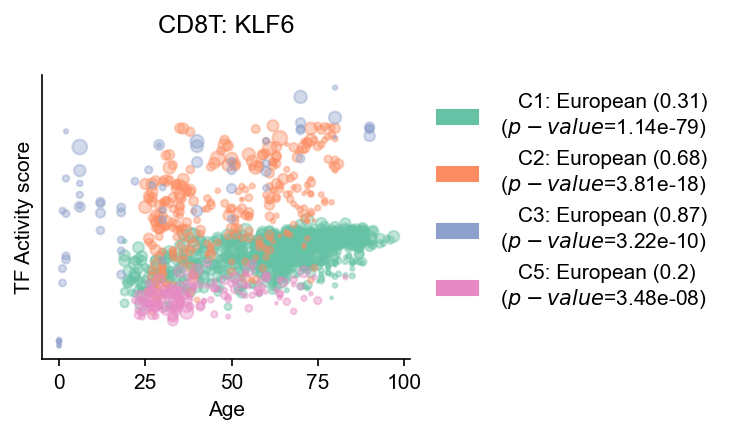

In [ ]:

from ciim.src.feature_association.plots import plot_trends
from ciim.src.common import palette_datasets, datasets_e
if True:
    datasets = datasets_e
    # # - load data
    if True:
        cell_type = 'CD8T'
        adata_complete = {dataset: retrieve_adata(dataset) for dataset in datasets}
        adata_dict = {dataset: adata[adata.obs['cell_type'] == cell_type] for dataset, adata in adata_complete.items()}
        nets_dict = {dataset: retrieve_net(dataset, cell_type) for dataset in datasets}
        tf_acts_dict = {}
        for dataset in datasets:
            tf_acts = calculate_tf_activity(adata_dict[dataset], nets_dict[dataset])
            print(tf_acts.shape)
            tf_acts_dict[surrogate_names[dataset]] = tf_acts

    cell_type = 'CD8T'
    genes = ['KLF6']
    
    plot_trends(top_tfs=genes, datasets=[surrogate_names[d] for d in datasets], data_dict=tf_acts_dict, palette=palette_datasets_pretty, cell_type=cell_type, surrogate_names=surrogate_names)
    plt.yticks([])
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/tf_activity/trends_{cell_type}_case.png', dpi=300)

# TF activity trend vs expression trend in aging


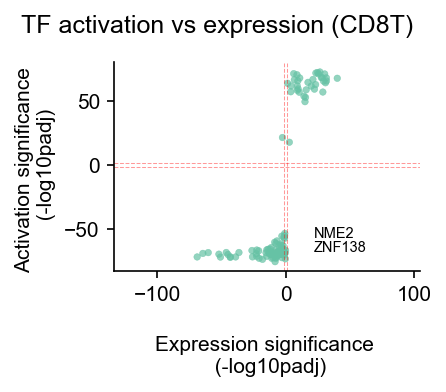

In [ ]:
from ciim.src.feature_association.plots import plot_activation_vs_expression

cell_type = 'CD8T'
os.makedirs(PLOTS_DIR, exist_ok=True)
stats_tfs = retrieve_sig_stats()
stats_targets = retrieve_sig_stats(feature_type='gene_expression')
stats_all = stats_tfs[['cell_type', 'tf', 'slope', 'p_value_adj', 'dataset']].merge(
    stats_targets[['cell_type', 'target', 'slope', 'p_value_adj', 'dataset']],
    left_on=['cell_type', 'tf', 'dataset'],
    right_on=['cell_type', 'target', 'dataset'],
    how='inner',
    suffixes=('_source', '_target')
)
stats_all = stats_all[stats_all['dataset'].isin(['data1'])]
stats_all['Activation significance'] = np.sign(stats_all['slope_source']) * -np.log10(stats_all['p_value_adj_source'].clip(lower=1e-300))
stats_all['Expression significance'] = np.sign(stats_all['slope_target']) * -np.log10(stats_all['p_value_adj_target'].clip(lower=1e-300))
df = stats_all[stats_all['cell_type'] == cell_type].copy()
plot_activation_vs_expression(df, col_x = 'Expression significance', 
                                  col_y = 'Activation significance', 
                                  y_label='Activation significance \n (-log10padj)', 
                                  x_label='Expression significance \n (-log10padj)', figsize=(3, 2.7))
plt.legend([],[], frameon=False)                               
plt.suptitle(f"TF activation vs expression ({cell_type})", y=.95, fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/activation_vs_expression.png', dpi=300)

array(['NME2', 'ZNF138', 'MAX', 'ZNF331', 'ZNF14'], dtype=object)